In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ตั้งค่าธีมการพล็อตกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

In [39]:
# อ่านไฟล์ข้อมูล data.csv
df = pd.read_csv('data.csv')

# เลือกเฉพาะ Feature (Weight และ Height)
feature_cols = ['Weight', 'Height']
X = df[feature_cols]

# สเกลข้อมูลด้วย StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- ข้อมูลตัวอย่าง 5 แถวแรก ---")
display(df.head())
print(f"จำนวนข้อมูลทั้งหมด: {X_scaled.shape[0]} แถว")

--- ข้อมูลตัวอย่าง 5 แถวแรก ---


,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


จำนวนข้อมูลทั้งหมด: 500 แถว


In [40]:
# นำเข้า KMeans โดยตรงเพื่อป้องกันปัญหา NameError
from sklearn.cluster import KMeans

# จัดกลุ่มด้วย K-Means (K=3) เพื่อสร้าง Target (y) ให้ SVM
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# กำหนดตัวแปร y
y = df['Cluster']

print("จำนวนข้อมูลในแต่ละกลุ่ม (ค่า y):")
print(y.value_counts().sort_index())

จำนวนข้อมูลในแต่ละกลุ่ม (ค่า y):
Cluster
0    128
1    125
2    247
Name: count, dtype: int64


In [41]:
# แบ่งข้อมูลเป็น Train Set (80%) และ Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"จำนวนข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูลสำหรับ Test: {X_test.shape[0]} แถว")

จำนวนข้อมูลสำหรับ Train: 400 แถว
จำนวนข้อมูลสำหรับ Test: 100 แถว


=== ผลการประเมินประสิทธิภาพโมเดล SVM ===
Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        49

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



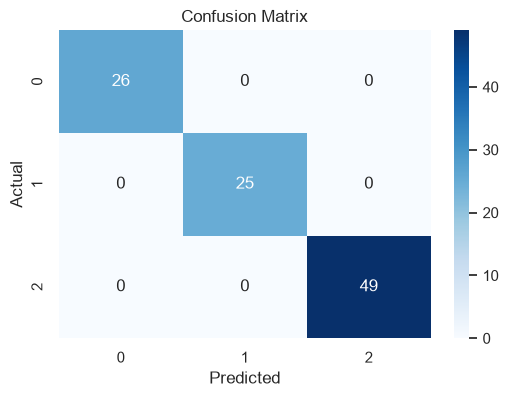

In [42]:
# สร้างและเทรนโมเดล Support Vector Classifier (SVC)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# ทำนายผลบน Test Set
y_pred = svm_model.predict(X_test)

# แสดงผลการประเมินประสิทธิภาพ
print("=== ผลการประเมินประสิทธิภาพโมเดล SVM ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# แสดง Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

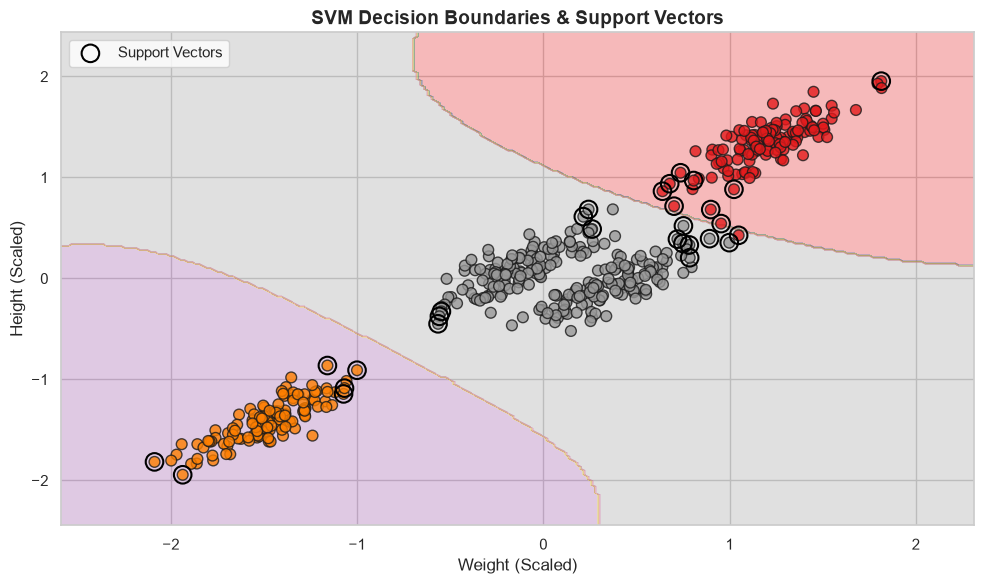

In [43]:
# สร้าง Meshgrid สำหรับวาดเส้นขอบเขตการตัดสินใจ
h = .02
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# ทำนายค่าทุกจุดบน Grid
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

# 1. แรสีพื้นที่ Decision Boundaries
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')

# 2. พล็อตจุดข้อมูลจริง
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], 
    c=y, cmap='Set1', edgecolors='k', s=60, alpha=0.8
)

# 3. พล็อตจุด Support Vectors
plt.scatter(
    svm_model.support_vectors_[:, 0], 
    svm_model.support_vectors_[:, 1], 
    s=160, 
    facecolors='none', 
    edgecolors='black', 
    linewidths=1.5, 
    label='Support Vectors'
)

plt.title('SVM Decision Boundaries & Support Vectors', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Scaled)', fontsize=12)
plt.ylabel('Height (Scaled)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()